This shows the distibution of FiLM parameters(initialized with identity) , features before and after applying filM when the initial image is passed throught the image backbone EfficientNet followed by 4 FiLMed Resblock each consist of FiLM 


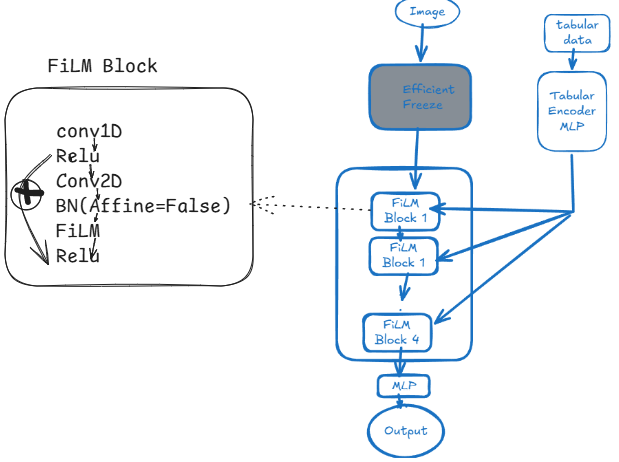

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../../../.."))

In [3]:
import os, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gc.enable()
import torch

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config

main_folder = "../../../.."
data_csv    = os.path.join(main_folder, "data", "train.csv")
img_folder  = os.path.join(main_folder, "data", "train")

# EXPERIMENT-SPECIFIC
cfg_key  = "exp12_film"  # or other key
exp_name = "exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone_identity_init"
out_dir  = os.path.join(main_folder, "outputs", "extra", exp_name)

df  = pd.read_csv(data_csv)
TARGET   = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

cfg = EXP_CONFIGS[cfg_key].copy()
cfg["name"] = exp_name

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Experiment:", cfg["name"])
print("Out dir:", out_dir)

Device: cuda
Experiment: exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone_identity_init
Out dir: ../../../../outputs/extra/exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone_identity_init


In [4]:
oof_path = os.path.join(out_dir, "oof_detail.csv")
df_oof   = pd.read_csv(oof_path)

fold_rmse_list = []
for f in range(1, cfg["n_splits"] + 1):
    sub  = df_oof[df_oof.fold == f]
    rmse = ((sub.ytrue - sub.oof_pred) ** 2).mean() ** 0.5
    fold_rmse_list.append((f, rmse))
    print(f"Fold {f} OOF RMSE: {rmse:.4f} (n={len(sub)})")

best_fold, best_rmse = min(fold_rmse_list, key=lambda x: x[1])
print(f"\nBest fold: {best_fold} (OOF RMSE={best_rmse:.4f})")

Fold 1 OOF RMSE: 19.7660 (n=1983)
Fold 2 OOF RMSE: 20.2001 (n=1983)
Fold 3 OOF RMSE: 19.5040 (n=1982)
Fold 4 OOF RMSE: 19.5261 (n=1982)
Fold 5 OOF RMSE: 20.1346 (n=1982)

Best fold: 3 (OOF RMSE=19.5040)


In [5]:
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader
from src.data import build_transforms, ImageTabDataset

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
splits = list(kf.split(df))
tr_idx, val_idx = splits[best_fold - 1]

val_df = df.iloc[val_idx].reset_index(drop=True)
val_tf = build_transforms(cfg["img_size"], cfg["aug"], train=False)
val_ds = ImageTabDataset(val_df, img_folder, tab_cols, val_tf)

val_loader = DataLoader(
    val_ds, batch_size=32, shuffle=False,
    num_workers=16, pin_memory=True,
)

print("Val size (best fold):", len(val_ds))

Val size (best fold): 1982


In [6]:
from src.film import FiLMExternalModulation

def build_best_model_external(cfg, tab_cols, best_fold, out_dir, device):
    model = FiLMExternalModulation(
        backbone_name        = cfg["backbone"],   # "efficientnet_b1" "
        tab_input_dim        = len(tab_cols),
        tab_hidden           = 64,                # match training (checkpoint)
        num_film_blocks      = 4,                 # same as training
        pretrained_backbone  = False,             # weights come from checkpoint
        freeze_backbone      = False,
        tab_encoder_capacity = "small",   
        identity_init=True        
    )

    ckpt_path = os.path.join(out_dir, f"model_fold{best_fold}.pt")
    state = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(state, strict=True)
    model.to(device).eval()
    print("Loaded:", ckpt_path)
    return model
analysis_model = build_best_model_external(cfg, tab_cols, best_fold, out_dir, device)

/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: ../../../../outputs/extra/exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone_identity_init/model_fold3.pt


In [7]:
from src.film_analysis import collect_film_stats

gamma, beta, feat_before, feat_after = collect_film_stats(
    analysis_model, val_loader, device, max_batches=None
)
print("FiLM blocks found:", sorted(gamma.keys()))

FiLM blocks found: [0, 1, 2, 3]


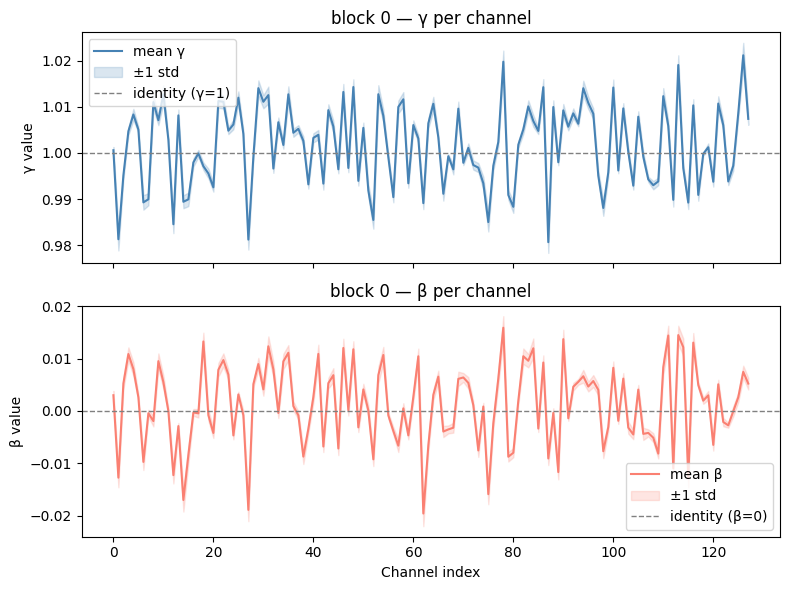

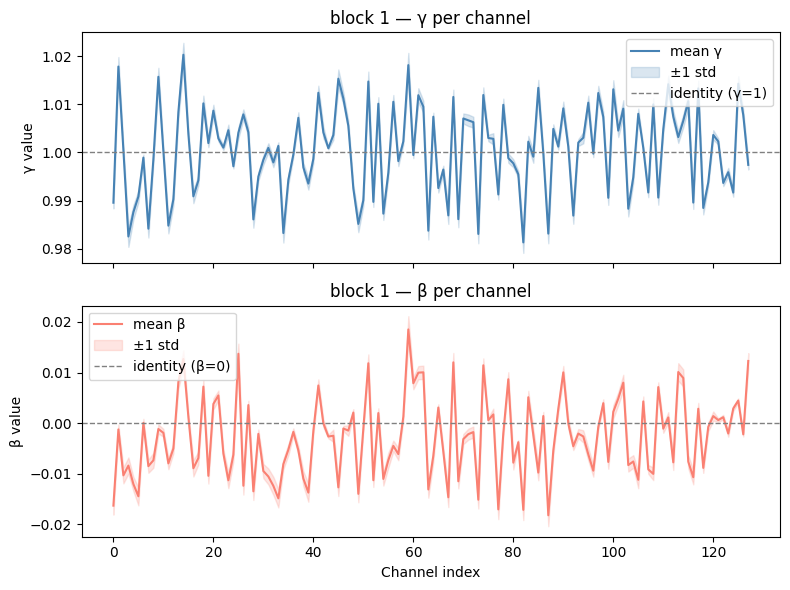

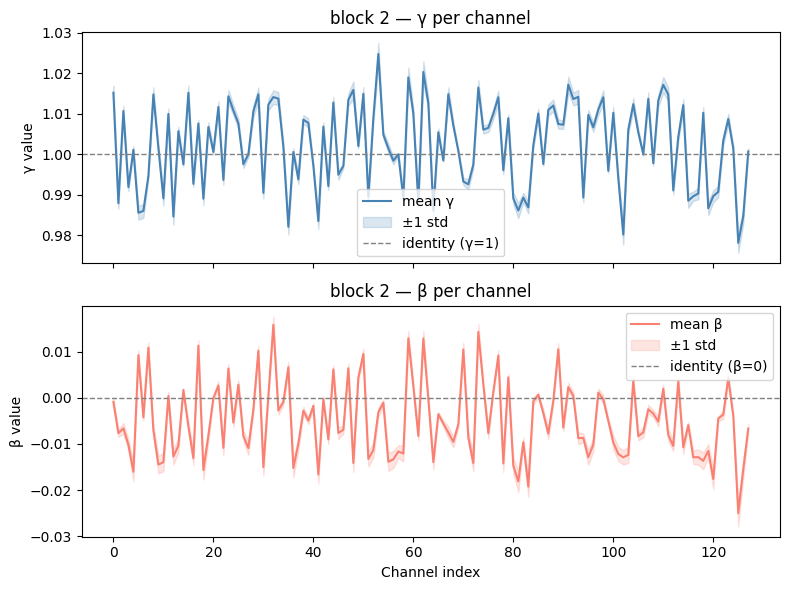

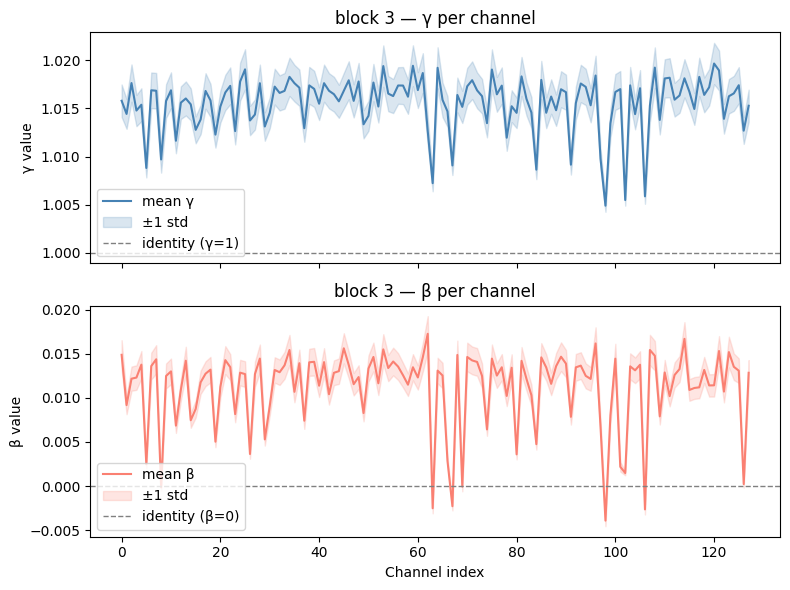

In [8]:
from src.film_analysis import plot_gamma_beta_per_channel

plot_gamma_beta_per_channel(
    gamma   = gamma,
    beta    = beta,
    exp_name = cfg["name"],
    out_dir  = out_dir,
)


[FiLM] Block 0  — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone_identity_init
  gamma shape:       (1982, 128)
  beta shape:        (1982, 128)
  feat_before shape: (1982, 128, 14, 14)
  feat_after shape:  (1982, 128, 14, 14)


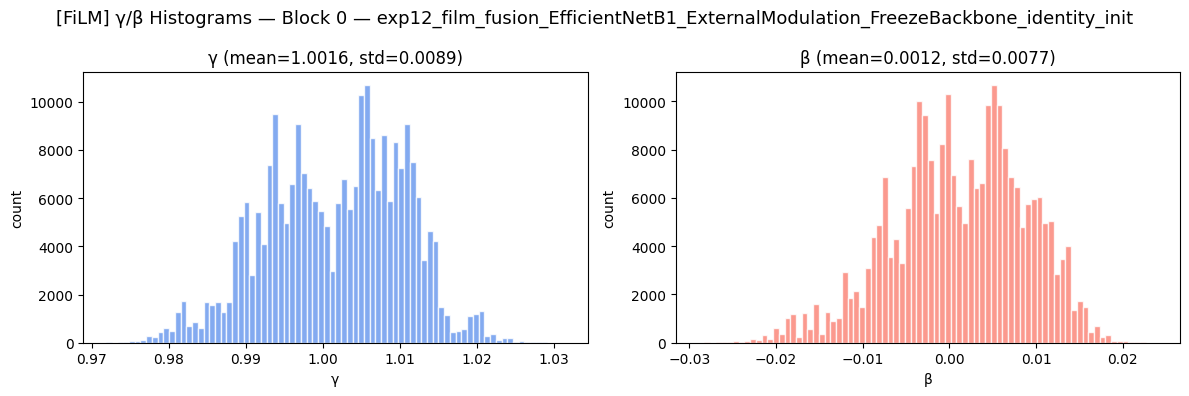

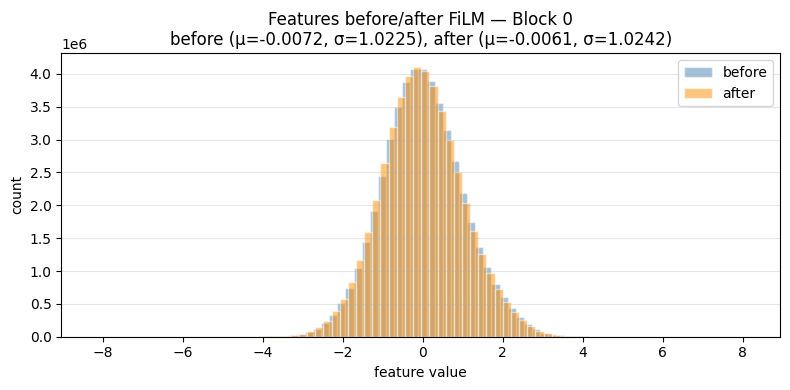

,block_idx,sample_idx,channel,h,w,before,after,gamma,beta,abs_diff
0,0,0,0,0,0,0.400514,0.404399,1.001045,0.003467,0.003885
1,0,0,0,0,1,-0.093903,-0.090535,1.001045,0.003467,0.003369
2,0,0,0,0,2,-0.256791,-0.253592,1.001045,0.003467,0.003198
3,0,0,0,0,3,-0.283618,-0.280448,1.001045,0.003467,0.003170
4,0,0,0,0,4,-0.016590,-0.013141,1.001045,0.003467,0.003449
...,...,...,...,...,...,...,...,...,...,...
16380,0,0,83,8,0,2.463109,2.500566,1.010896,0.010620,0.037457
16381,0,0,83,8,1,1.129314,1.152238,1.010896,0.010620,0.022924
16382,0,0,83,8,2,0.880614,0.900828,1.010896,0.010620,0.020214
16383,0,0,83,8,3,0.095331,0.106989,1.010896,0.010620,0.011658


[FiLM] Block 0 global stats:
  L2 ||after - before|| = 85.3655


,block_idx,which,min,max,mean,std
0,0,before,-8.216929,8.001189,-0.007165,1.022546
1,0,after,-8.186621,8.110165,-0.006117,1.024202



[FiLM] Block 1  — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone_identity_init
  gamma shape:       (1982, 128)
  beta shape:        (1982, 128)
  feat_before shape: (1982, 128, 14, 14)
  feat_after shape:  (1982, 128, 14, 14)


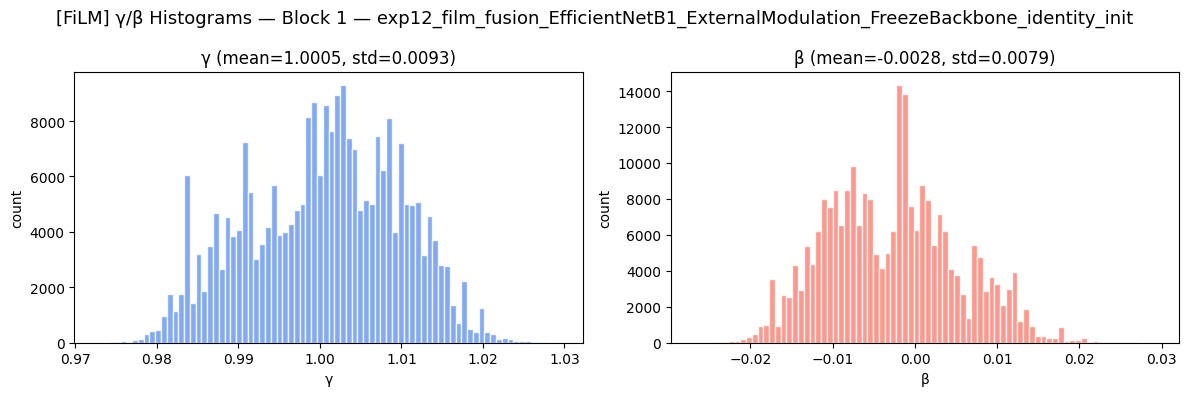

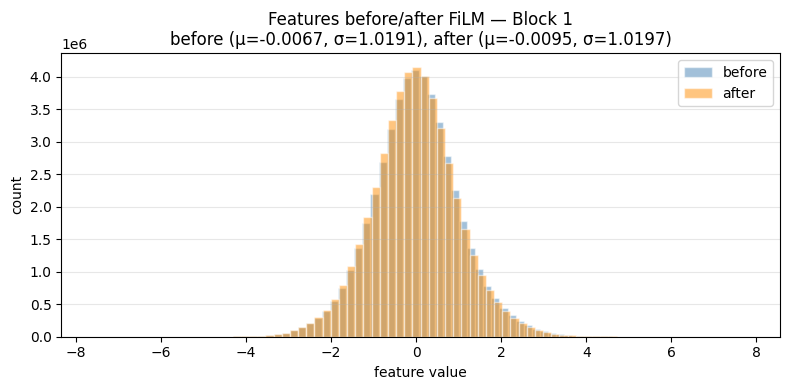

,block_idx,sample_idx,channel,h,w,before,after,gamma,beta,abs_diff
0,1,0,0,0,0,-3.308290,-3.287243,0.988391,-0.017359,0.021047
1,1,0,0,0,1,-4.219718,-4.188090,0.988391,-0.017359,0.031628
2,1,0,0,0,2,-2.587862,-2.575178,0.988391,-0.017359,0.012684
3,1,0,0,0,3,-1.830120,-1.826233,0.988391,-0.017359,0.003887
4,1,0,0,0,4,-2.189014,-2.180961,0.988391,-0.017359,0.008053
...,...,...,...,...,...,...,...,...,...,...
16380,1,0,83,8,0,-0.767089,-0.763323,1.002824,0.005932,0.003766
16381,1,0,83,8,1,1.399607,1.409492,1.002824,0.005932,0.009885
16382,1,0,83,8,2,0.587489,0.595081,1.002824,0.005932,0.007591
16383,1,0,83,8,3,0.718422,0.726383,1.002824,0.005932,0.007961


[FiLM] Block 1 global stats:
  L2 ||after - before|| = 89.4886


,block_idx,which,min,max,mean,std
0,1,before,-7.519136,7.648362,-0.006676,1.019107
1,1,after,-7.575744,7.789159,-0.009522,1.019671



[FiLM] Block 2  — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone_identity_init
  gamma shape:       (1982, 128)
  beta shape:        (1982, 128)
  feat_before shape: (1982, 128, 14, 14)
  feat_after shape:  (1982, 128, 14, 14)


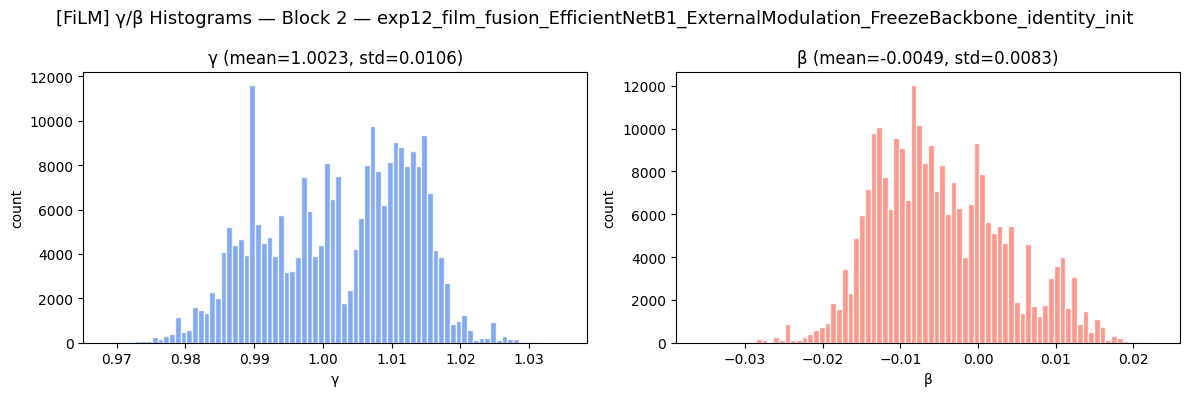

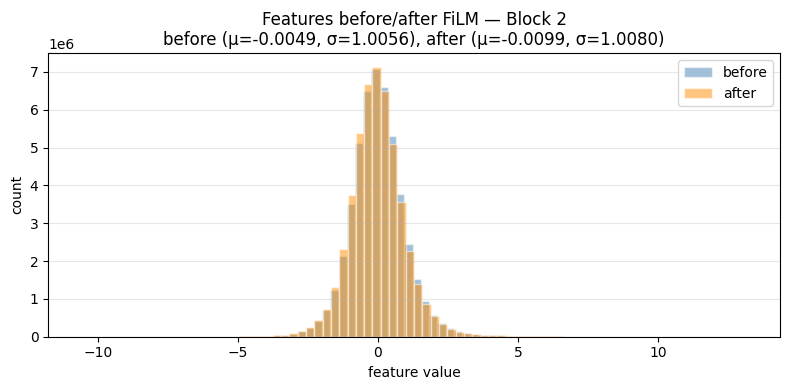

,block_idx,sample_idx,channel,h,w,before,after,gamma,beta,abs_diff
0,2,0,0,0,0,0.196704,0.199379,1.015889,-0.000450,0.002675
1,2,0,0,0,1,4.536230,4.607856,1.015889,-0.000450,0.071626
2,2,0,0,0,2,2.013072,2.044608,1.015889,-0.000450,0.031535
3,2,0,0,0,3,0.670856,0.681064,1.015889,-0.000450,0.010209
4,2,0,0,0,4,0.696045,0.706654,1.015889,-0.000450,0.010609
...,...,...,...,...,...,...,...,...,...,...
16380,2,0,83,8,0,1.012829,0.978152,0.985868,-0.020362,0.034676
16381,2,0,83,8,1,-0.623282,-0.634836,0.985868,-0.020362,0.011554
16382,2,0,83,8,2,-0.172451,-0.190376,0.985868,-0.020362,0.017925
16383,2,0,83,8,3,0.380163,0.354428,0.985868,-0.020362,0.025735


[FiLM] Block 2 global stats:
  L2 ||after - before|| = 102.6888


,block_idx,which,min,max,mean,std
0,2,before,-10.516272,12.992953,-0.004912,1.005581
1,2,after,-10.582730,13.163083,-0.009915,1.007958



[FiLM] Block 3  — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone_identity_init
  gamma shape:       (1982, 128)
  beta shape:        (1982, 128)
  feat_before shape: (1982, 128, 14, 14)
  feat_after shape:  (1982, 128, 14, 14)


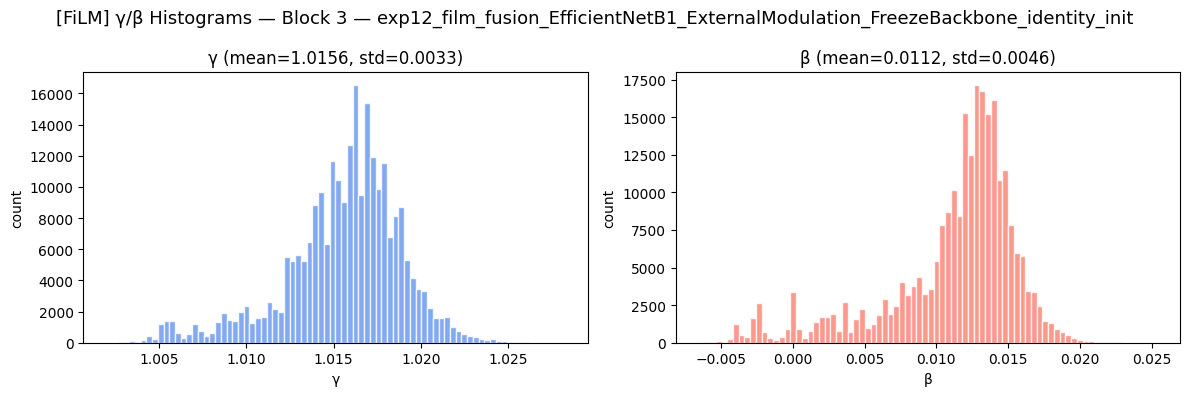

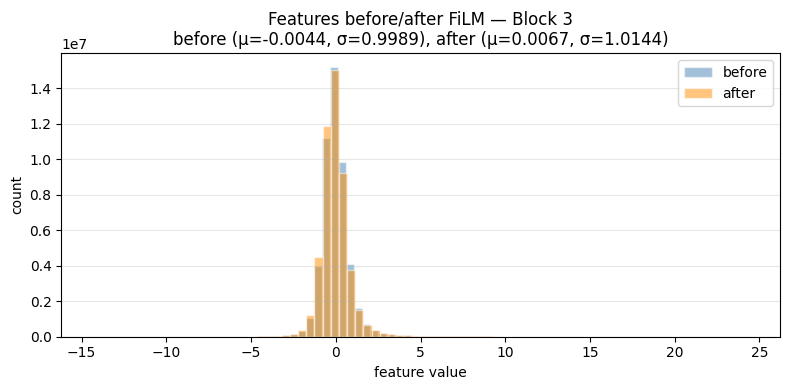

,block_idx,sample_idx,channel,h,w,before,after,gamma,beta,abs_diff
0,3,0,0,0,0,1.535937,1.576483,1.016278,0.015544,0.040546
1,3,0,0,0,1,6.943497,7.072068,1.016278,0.015544,0.128571
2,3,0,0,0,2,1.631272,1.673370,1.016278,0.015544,0.042098
3,3,0,0,0,3,0.062573,0.079136,1.016278,0.015544,0.016563
4,3,0,0,0,4,0.116020,0.133452,1.016278,0.015544,0.017433
...,...,...,...,...,...,...,...,...,...,...
16380,3,0,83,8,0,-0.334133,-0.328614,1.015023,0.010539,0.005519
16381,3,0,83,8,1,1.709783,1.746008,1.015023,0.010539,0.036226
16382,3,0,83,8,2,-0.191367,-0.183703,1.015023,0.010539,0.007664
16383,3,0,83,8,3,0.328156,0.343625,1.015023,0.010539,0.015469


[FiLM] Block 3 global stats:
  L2 ||after - before|| = 140.4555


,block_idx,which,min,max,mean,std
0,3,before,-14.129786,23.897394,-0.00444,0.998880
1,3,after,-14.273234,24.288450,0.00668,1.014429


In [9]:
from src.film_analysis import analyze_film_per_block

analyze_film_per_block(
    gamma       = gamma,
    beta        = beta,
    feat_before = feat_before, #feature before FiLM 
    feat_after  = feat_after, # feature after FiLM 
    exp_name    = cfg["name"],
    out_dir     = out_dir,
    n_table_rows = 16385, 
)


[FiLM per-channel] Block 0 — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone_identity_init
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


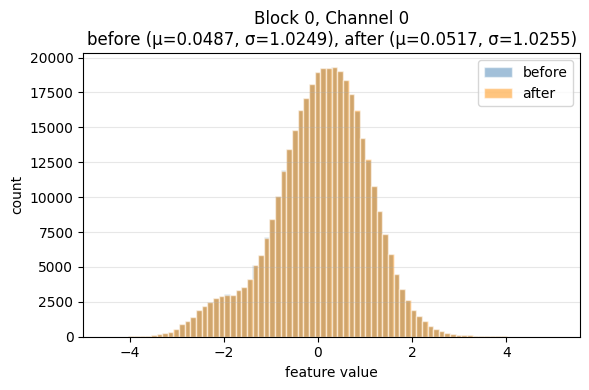

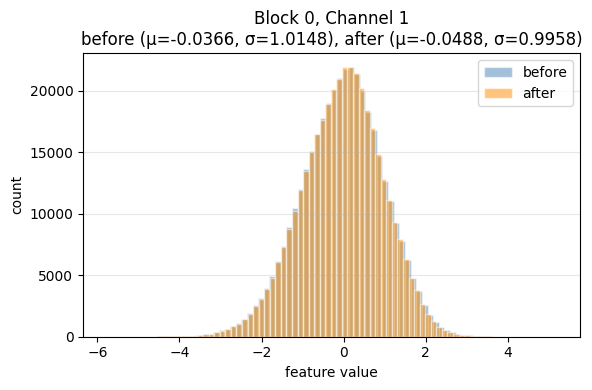

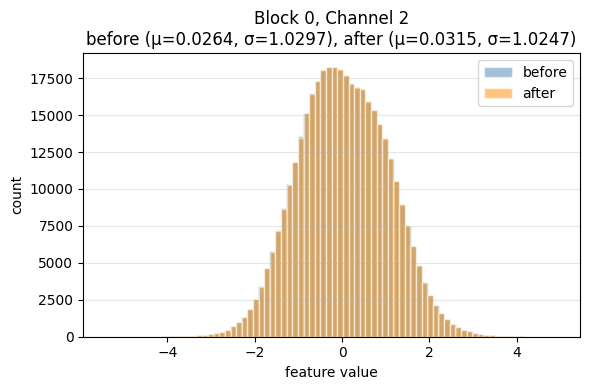

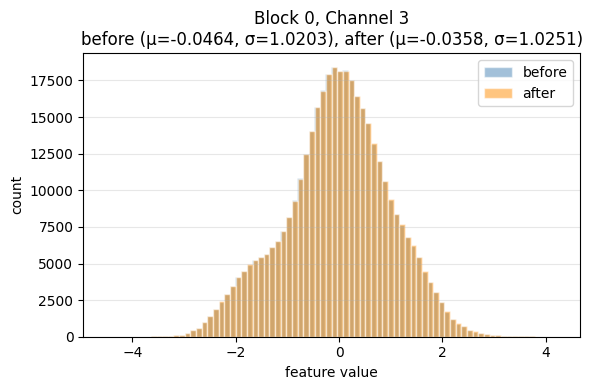


[FiLM per-channel] Block 1 — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone_identity_init
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


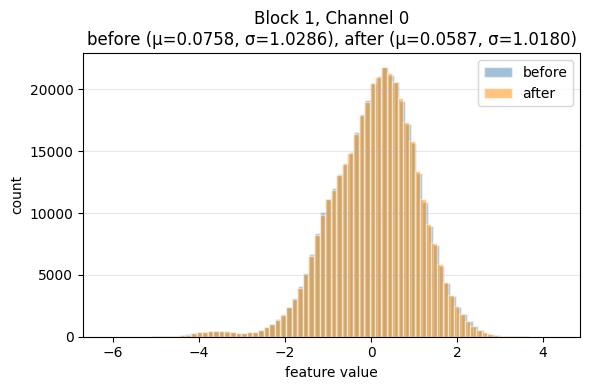

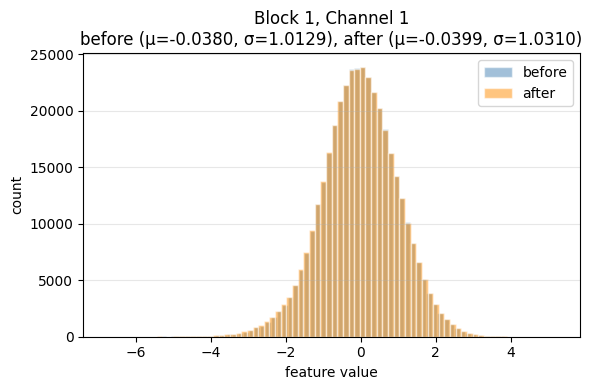

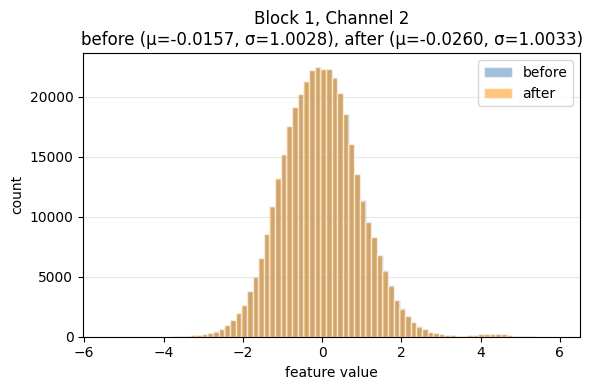

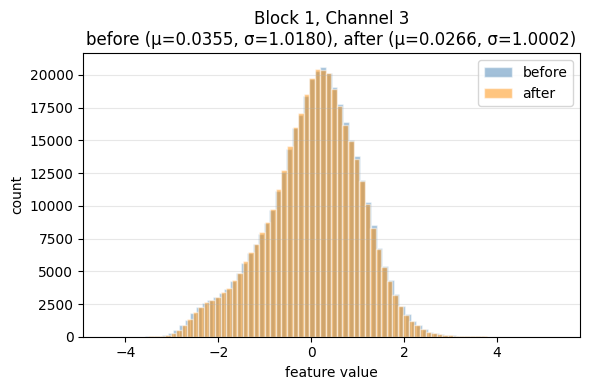


[FiLM per-channel] Block 2 — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone_identity_init
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


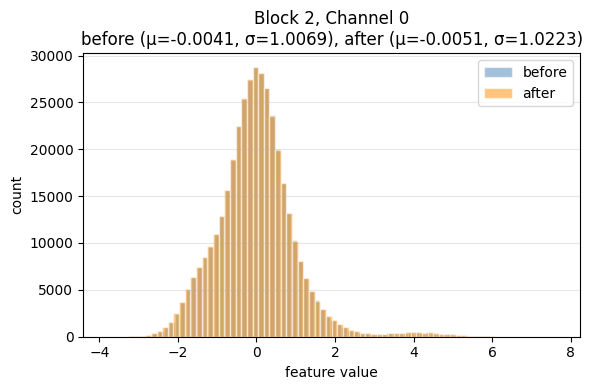

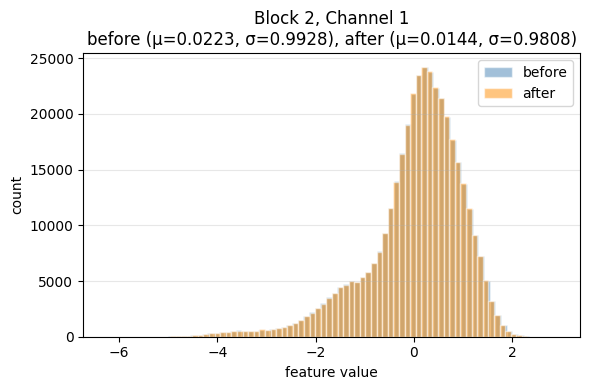

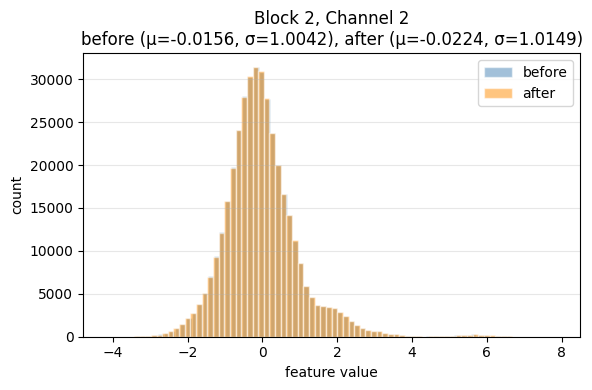

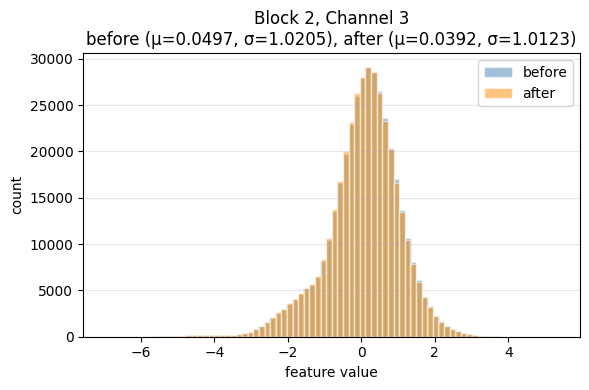


[FiLM per-channel] Block 3 — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone_identity_init
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


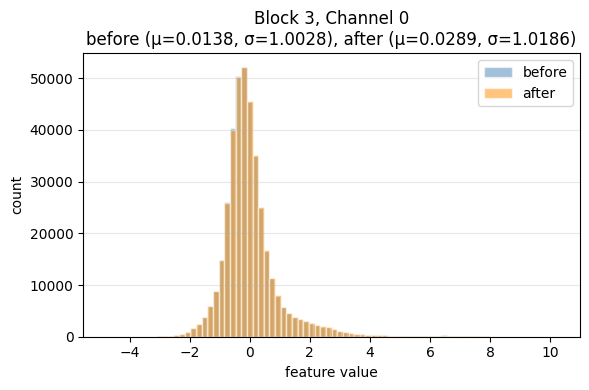

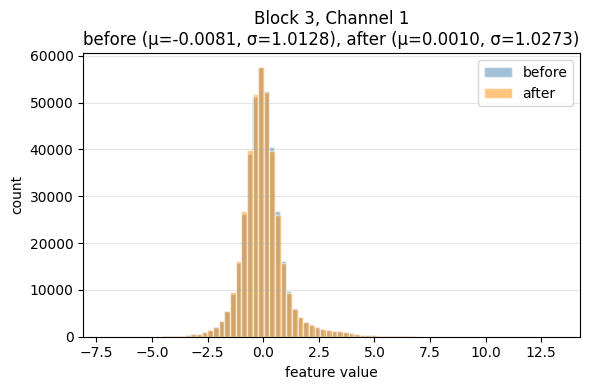

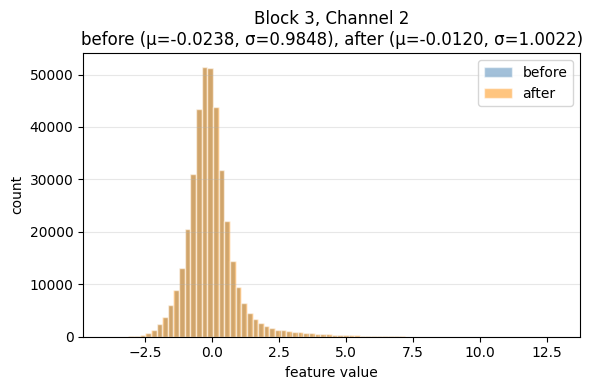

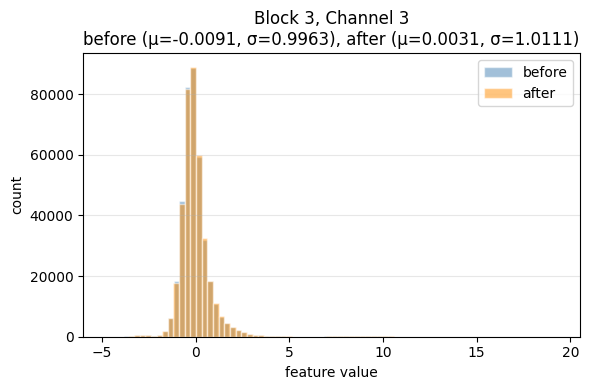

In [10]:
from src.film_analysis import analyze_film_per_channel
analyze_film_per_channel(
    feat_before = feat_before,
    feat_after  = feat_after,
    exp_name    = cfg["name"],
    out_dir     = out_dir,
    max_channels = 4,   # e.g. first 4 channels
)


[FiLM per-sample] Block 0 — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone_identity_init
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


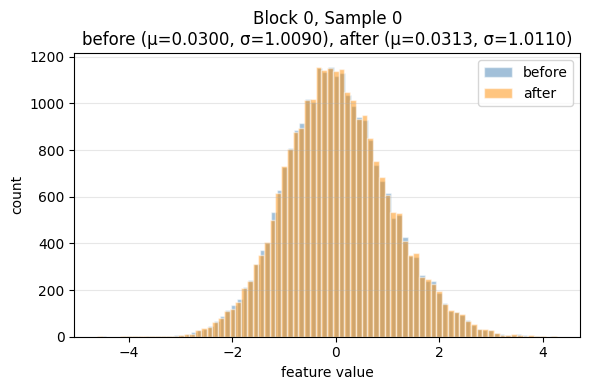

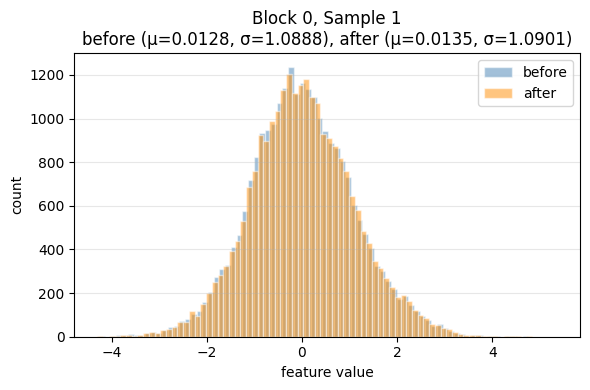

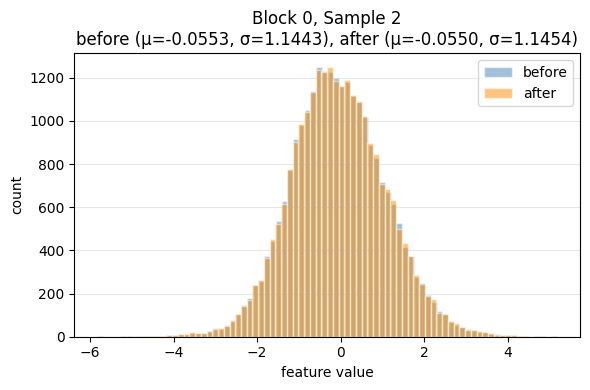

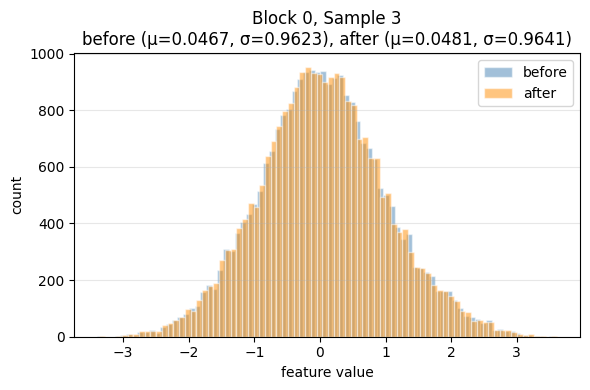


[FiLM per-sample] Block 1 — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone_identity_init
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


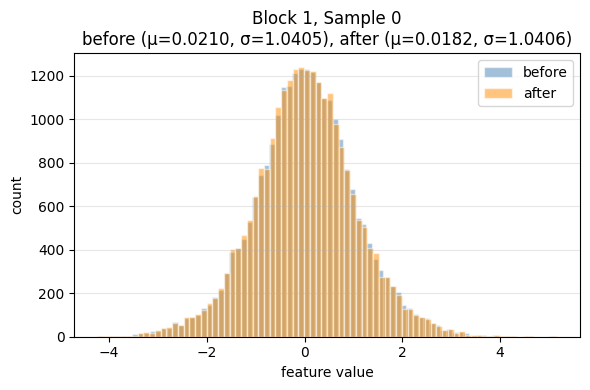

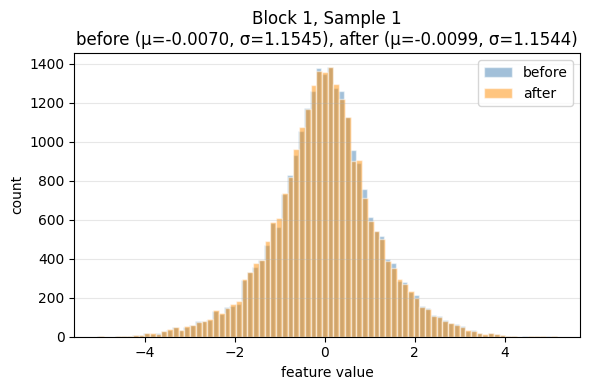

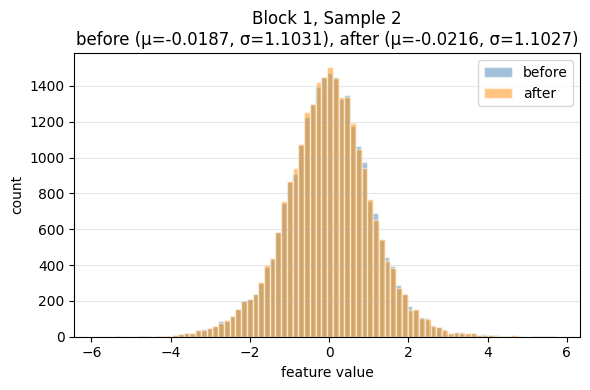

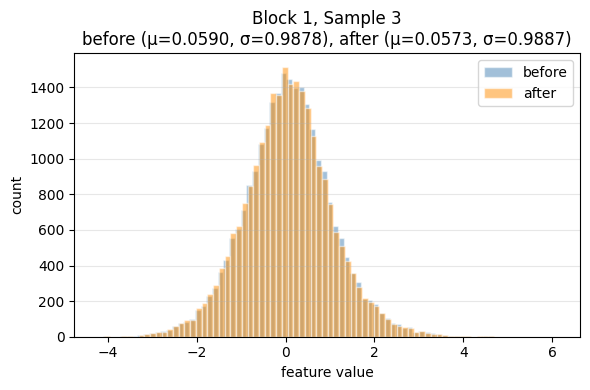


[FiLM per-sample] Block 2 — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone_identity_init
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


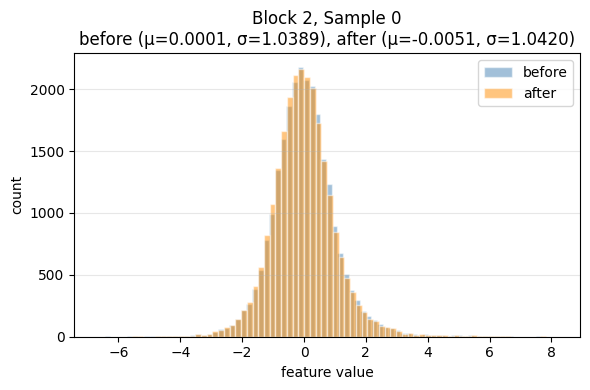

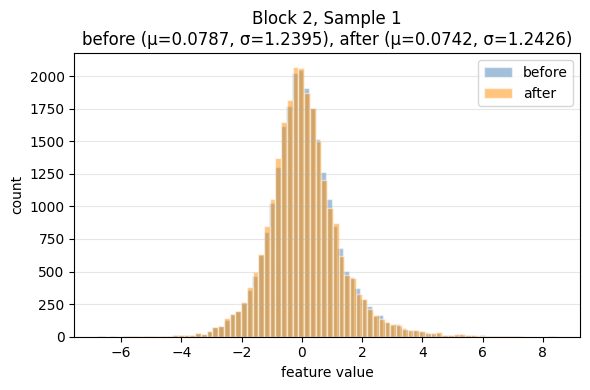

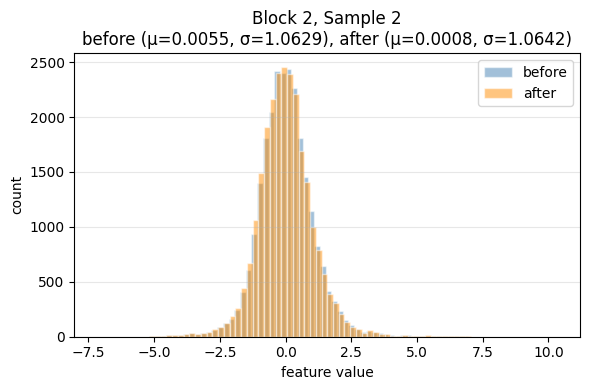

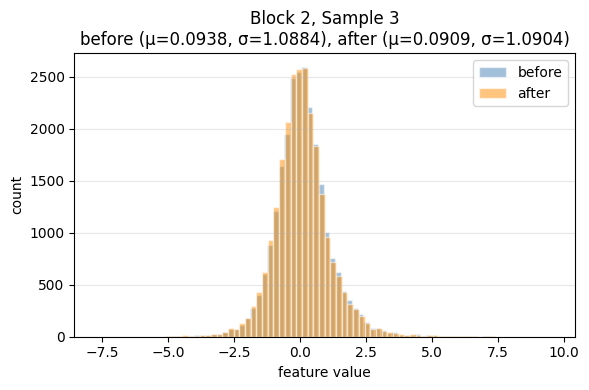


[FiLM per-sample] Block 3 — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone_identity_init
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


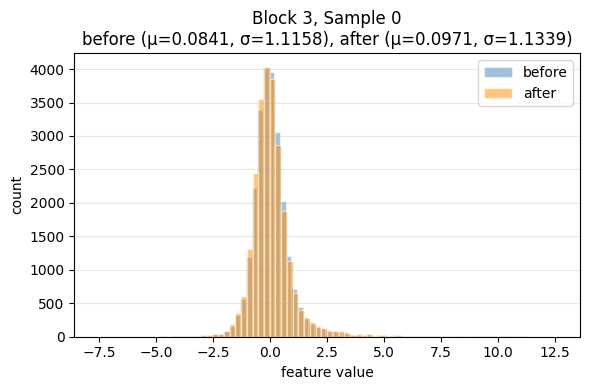

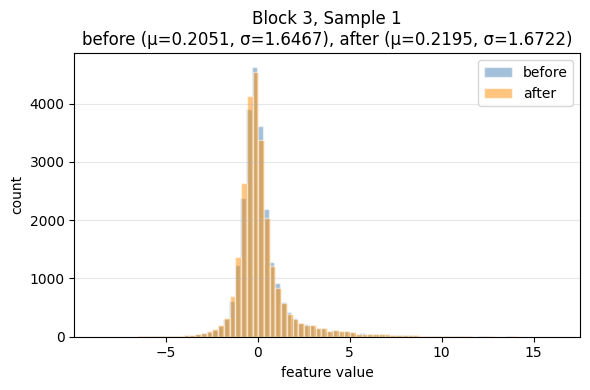

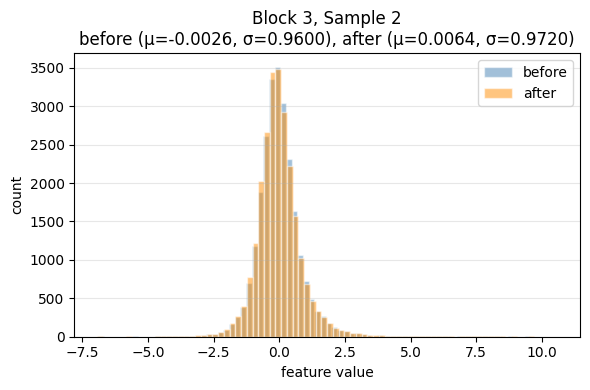

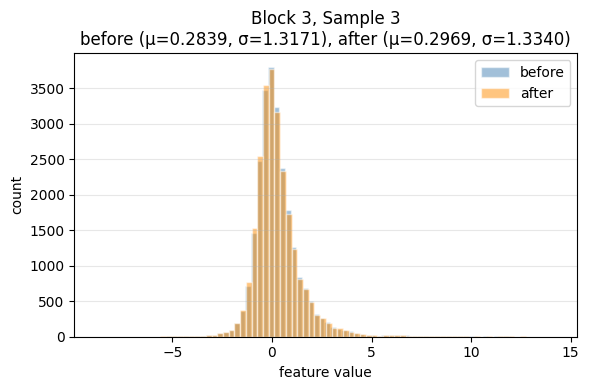

In [11]:
from src.film_analysis import analyze_film_per_sample
analyze_film_per_sample(
    feat_before = feat_before,
    feat_after  = feat_after,
    exp_name    = cfg["name"],
    out_dir     = out_dir,
    max_samples = 4,   # e.g. first 4 samples
)